In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

### Transmonin määrittely

In [3]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

#Ajotaajuudet
f_1=1.2*qubit.frequency
f_2=1.4*qubit.frequency

In [4]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [5]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman"]
plt.rcParams["font.size"] = 21

plt.rcParams["mathtext.fontset"] = "stix"

## Simulaatio

In [6]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [7]:
def sim_pulse(f_1,f_2,A,evolution,dim,f_rabi,K=20):
    T_floquet = 10*np.pi/(2*f_1-f_2) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_1,f_ef,[pulses.one],[N_pulse],time_unit=dt,second_frequency=f_2)
    U_floquet=evolution.U_floquet(A*pulse.raw[0:K],dt)
    
    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1
    
    psi = np.zeros((N_sim, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0,0] = 1
    
    #Simulaatio pulsseille
    for i in range(1,N_sim):
        psi[i] = U_floquet @ psi[i-1] #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([np.abs(a[1])**2 for a in psi])
    f_vals = np.array([np.abs(a[2])**2 for a in psi])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,psi,pulse_times)

def find_params(q,A,evolution,f_rabi,c_guess):

    #Rajat AC-stark siirtymälle
    min_range = -200
    max_range = 200
    
    scale = 20000
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range,max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        
        delta=q.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse(f_1_shifted,f_2_shifted,A,evolution,dim,f_rabi,K=200)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    print(AC_stark_vals)
    print(max_e_vals)
    plt.xlabel("$\delta$ (GHz)")
    plt.ylabel("Maximum population of the e-state")
    
    ax = plt.gca()
    
    ax.text(0.02, 0.98, "(c)",
        transform=ax.transAxes,
        va="top",
        fontweight="bold",
        fontsize=16)
    
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

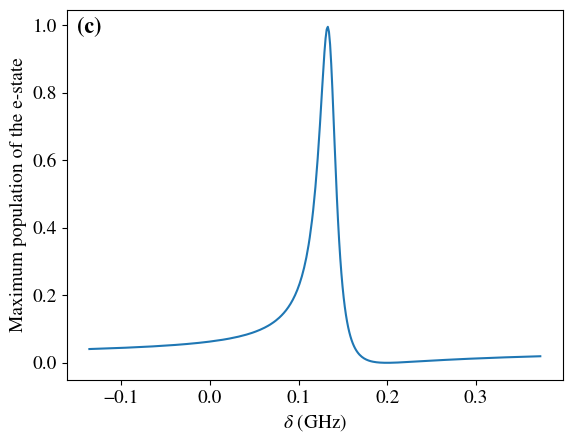

Amplitudi (GHz): 1.7842020972656034
AC-stark siirtymä (GHz): 0.13296951744681706
E-tason suurin todennäköisyys: 0.9948738131217567
Pulssin pituus (ns): 277.53863834074144
Rabi-taajuus (fourier):  0.0018067938874667755


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

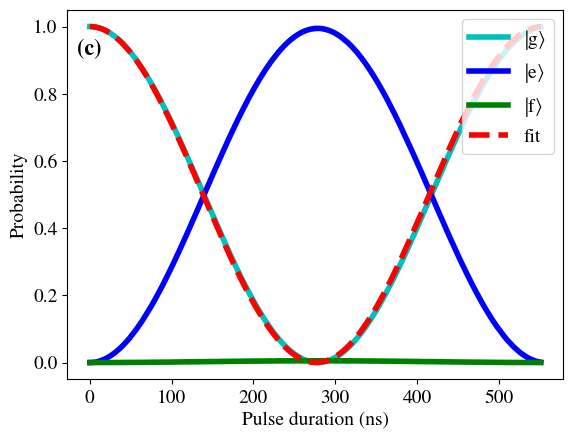

---------------------------------------------


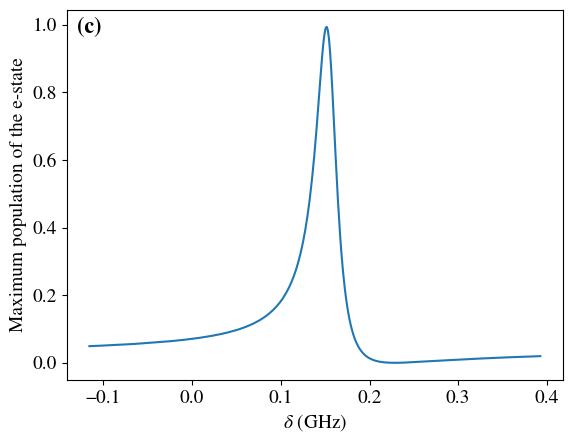

Amplitudi (GHz): 1.9049375775316966
AC-stark siirtymä (GHz): 0.15173105105078122
E-tason suurin todennäköisyys: 0.9941291228200401
Pulssin pituus (ns): 226.90705202619154
Rabi-taajuus (fourier):  0.0022737457890295953


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

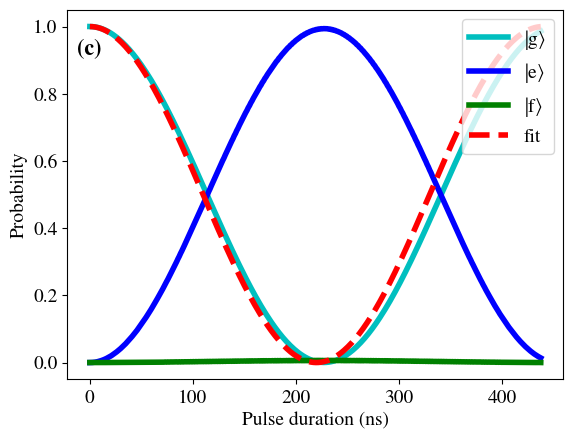

---------------------------------------------


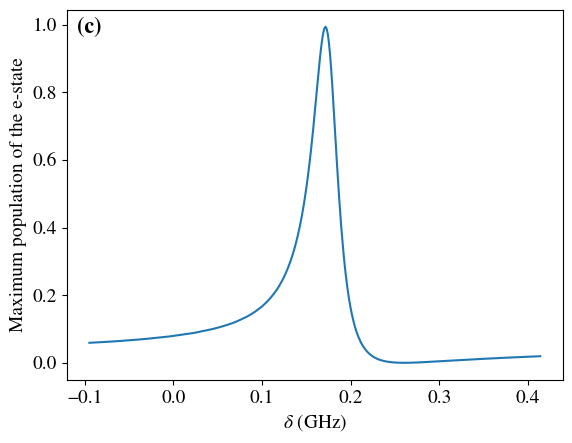

Amplitudi (GHz): 2.0256730577977904
AC-stark siirtymä (GHz): 0.17158568115016948
E-tason suurin todennäköisyys: 0.9935623419690238
Pulssin pituus (ns): 187.37614897297766
Rabi-taajuus (fourier):  0.002775975331946544


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

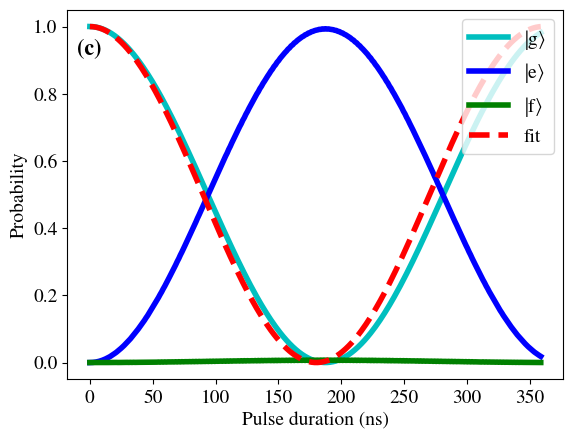

---------------------------------------------


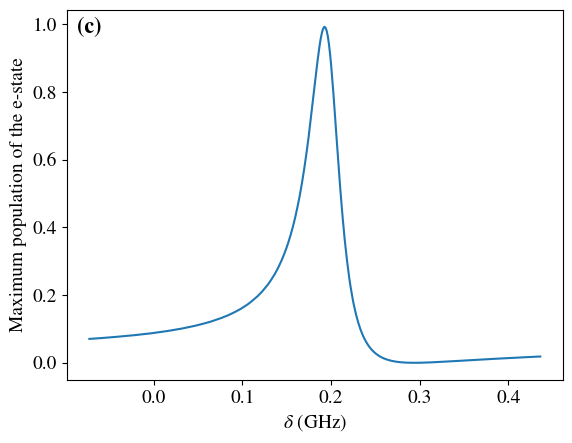

Amplitudi (GHz): 2.1464085380638838
AC-stark siirtymä (GHz): 0.19253340774498184
E-tason suurin todennäköisyys: 0.9927109879609143
Pulssin pituus (ns): 155.24115525852778
Rabi-taajuus (fourier):  0.003323148378114987


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

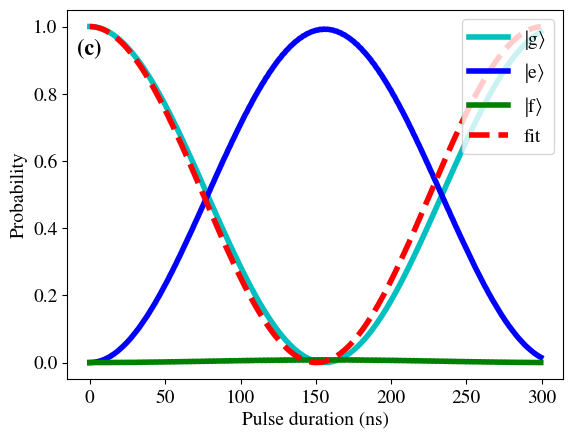

---------------------------------------------


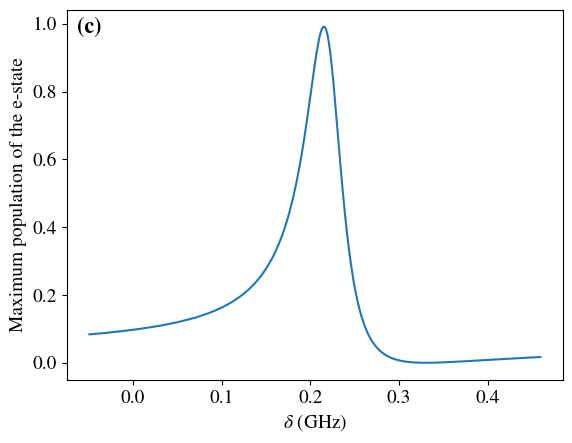

Amplitudi (GHz): 2.267144018329977
AC-stark siirtymä (GHz): 0.21584866090470456
E-tason suurin todennäköisyys: 0.9912990907478213
Pulssin pituus (ns): 131.76594764195033
Rabi-taajuus (fourier):  0.003926094214052219


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

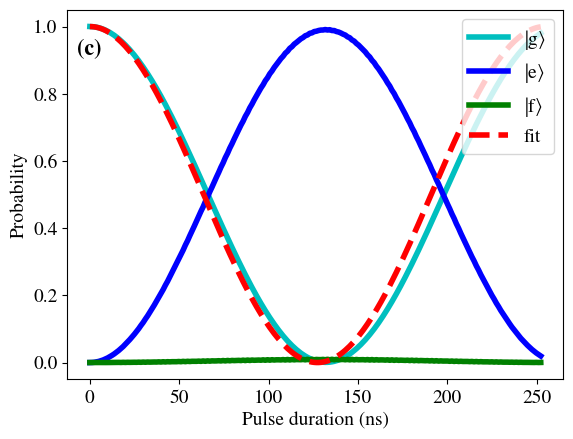

---------------------------------------------


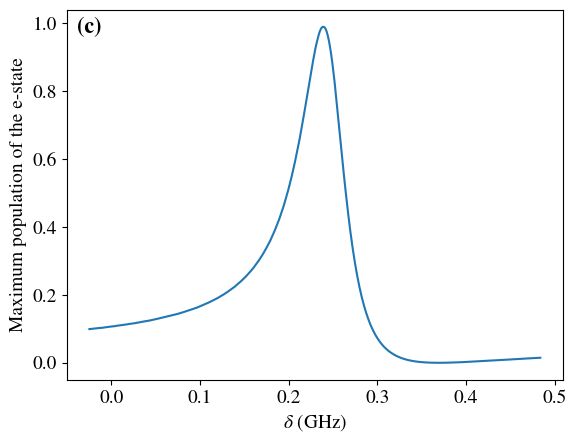

Amplitudi (GHz): 2.3878794985960705
AC-stark siirtymä (GHz): 0.23898258049037935
E-tason suurin todennäköisyys: 0.9908683356725931
Pulssin pituus (ns): 111.97925044400901
Rabi-taajuus (fourier):  0.004595313487297139


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

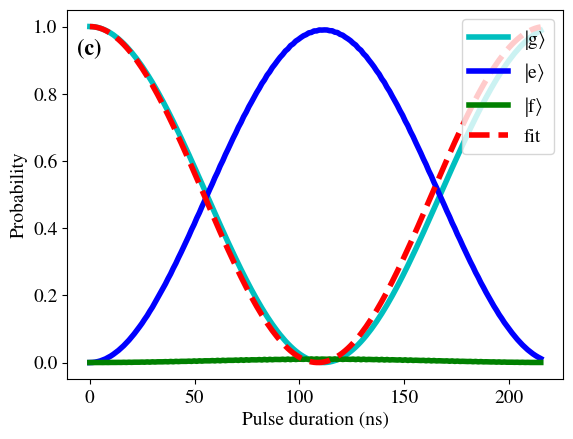

---------------------------------------------


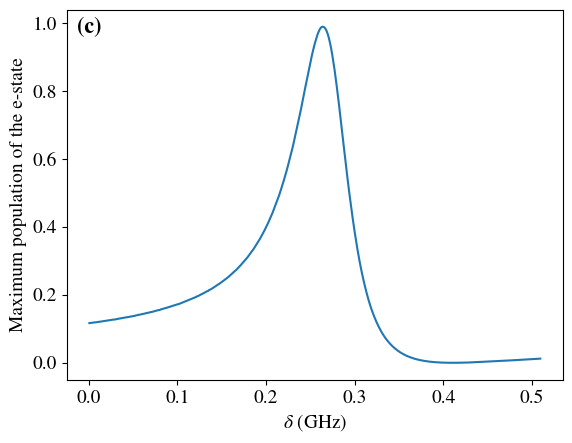

Amplitudi (GHz): 2.508614978862164
AC-stark siirtymä (GHz): 0.26320959657147824
E-tason suurin todennäköisyys: 0.9894382309963332
Pulssin pituus (ns): 93.40566479732759
Rabi-taajuus (fourier):  0.005342309774152593


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

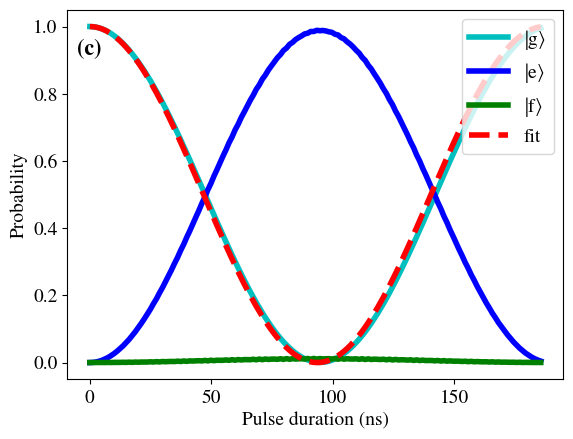

---------------------------------------------


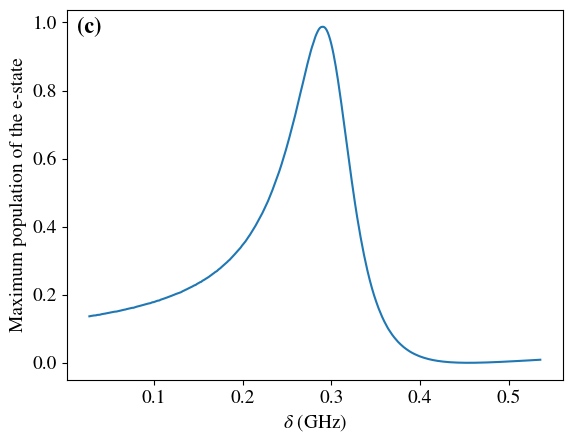

Amplitudi (GHz): 2.6293504591282577
AC-stark siirtymä (GHz): 0.2898041392174946
E-tason suurin todennäköisyys: 0.9887136051365525
Pulssin pituus (ns): 82.28373484553151
Rabi-taajuus (fourier):  0.006170020219006604


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

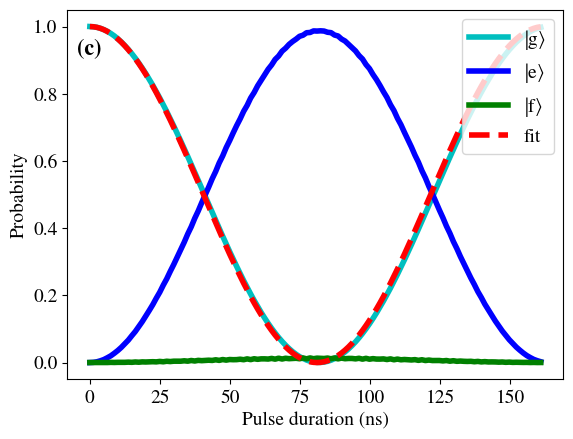

---------------------------------------------


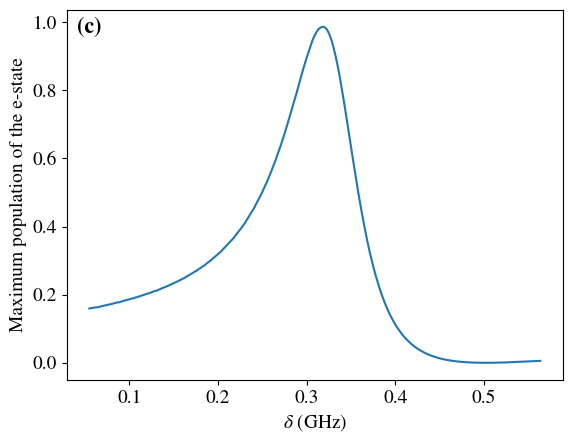

Amplitudi (GHz): 2.7500859393943506
AC-stark siirtymä (GHz): 0.3187662084284
E-tason suurin todennäköisyys: 0.987290220645149
Pulssin pituus (ns): 72.39315339068024
Rabi-taajuus (fourier):  0.007096374997125256


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

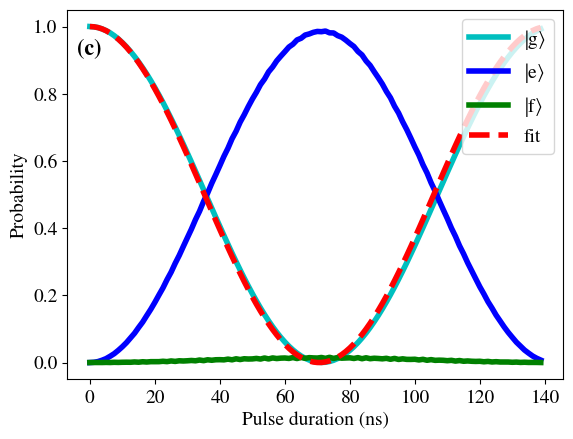

---------------------------------------------


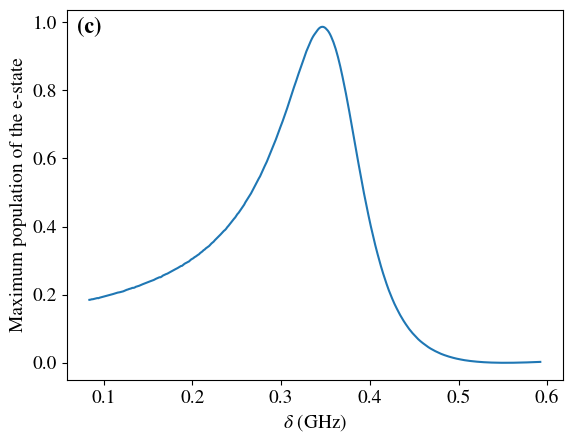

Amplitudi (GHz): 2.870821419660444
AC-stark siirtymä (GHz): 0.3462725139957925
E-tason suurin todennäköisyys: 0.9862995394978299
Pulssin pituus (ns): 61.22664323901459
Rabi-taajuus (fourier):  0.00813318276703244


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

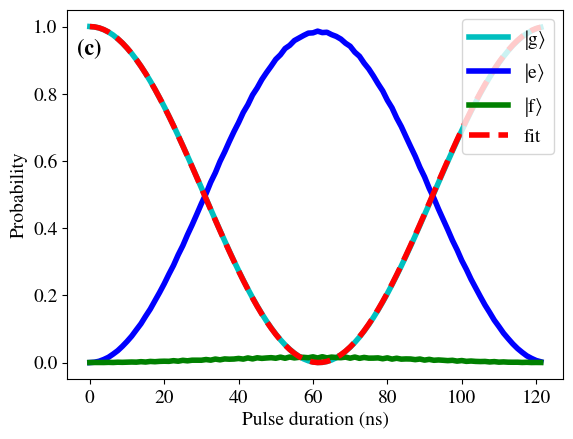

---------------------------------------------


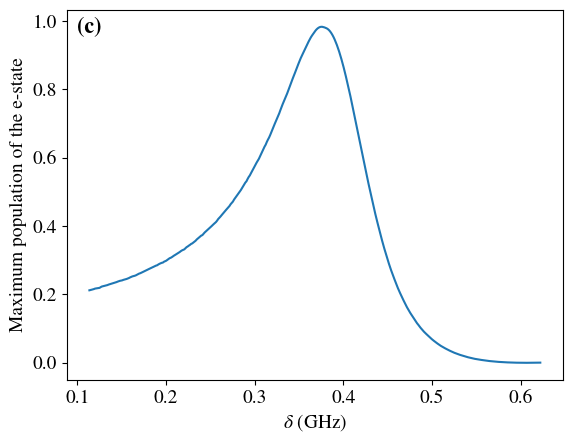

Amplitudi (GHz): 2.991556899926538
AC-stark siirtymä (GHz): 0.3761463461280883
E-tason suurin todennäköisyys: 0.9848331493835315
Pulssin pituus (ns): 52.542410219486534
Rabi-taajuus (fourier):  0.009284021726659717


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

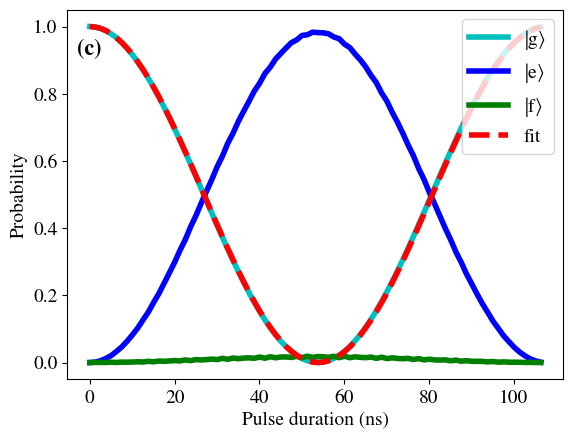

---------------------------------------------


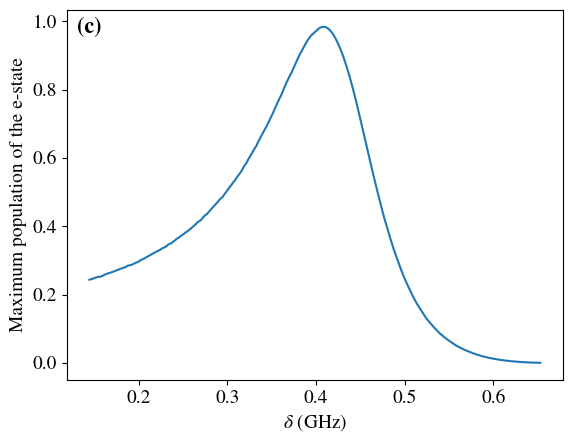

Amplitudi (GHz): 3.112292380192631
AC-stark siirtymä (GHz): 0.4083877048252873
E-tason suurin todennäköisyys: 0.9835451106069514
Pulssin pituus (ns): 47.599483137306244
Rabi-taajuus (fourier):  0.010559894131530025


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

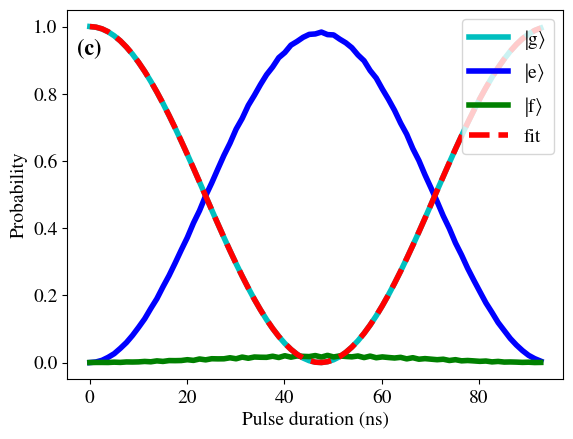

---------------------------------------------


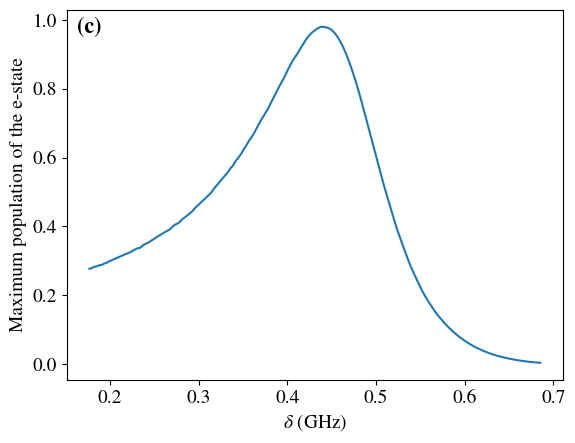

Amplitudi (GHz): 3.2330278604587246
AC-stark siirtymä (GHz): 0.43917329987896636
E-tason suurin todennäköisyys: 0.9807161498847845
Pulssin pituus (ns): 41.38719542718149
Rabi-taajuus (fourier):  0.01197219309936796


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

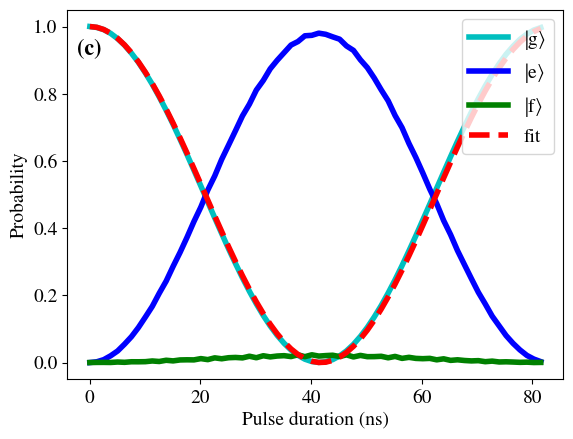

---------------------------------------------


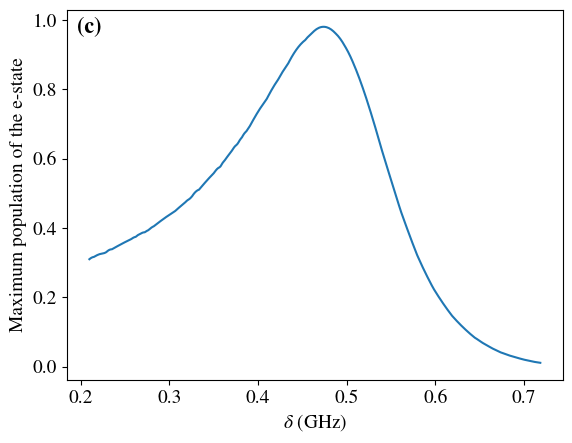

Amplitudi (GHz): 3.353763340724818
AC-stark siirtymä (GHz): 0.4736008515670278
E-tason suurin todennäköisyys: 0.9802004560228311
Pulssin pituus (ns): 36.42062162497993
Rabi-taajuus (fourier):  0.013541704037618452


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

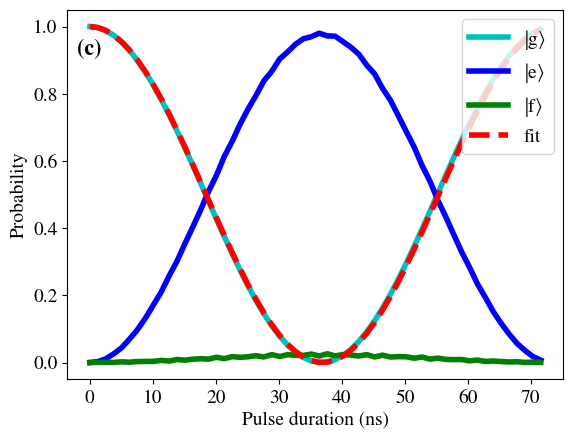

---------------------------------------------


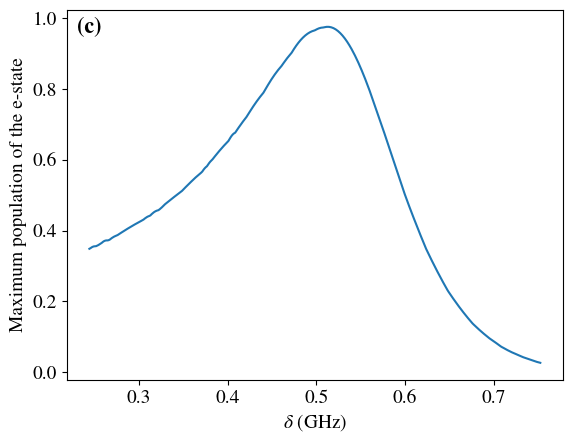

Amplitudi (GHz): 3.474498820990912
AC-stark siirtymä (GHz): 0.5129447899589437
E-tason suurin todennäköisyys: 0.9779371864046491
Pulssin pituus (ns): 33.962270945242665
Rabi-taajuus (fourier):  0.015259114029881183


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

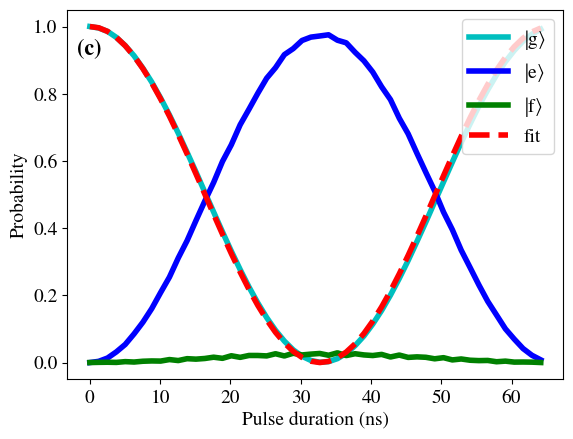

---------------------------------------------


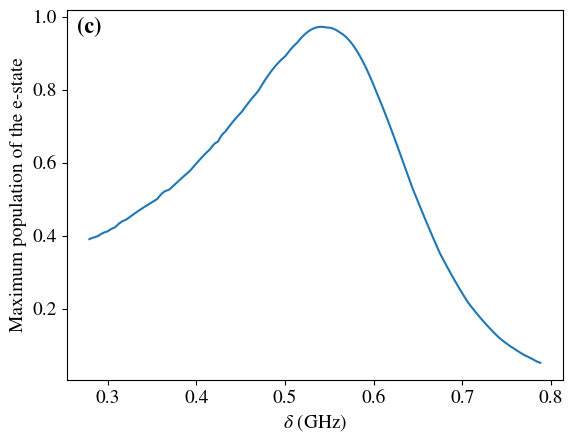

Amplitudi (GHz): 3.595234301257005
AC-stark siirtymä (GHz): 0.5406375241515349
E-tason suurin todennäköisyys: 0.9749131961639426
Pulssin pituus (ns): 27.703679046508913
Rabi-taajuus (fourier):  0.017151584316412824


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

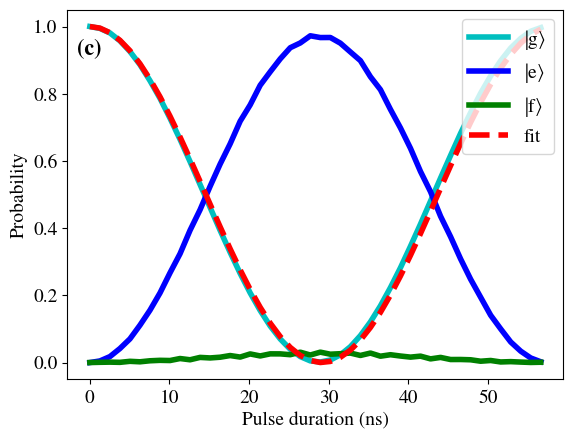

---------------------------------------------


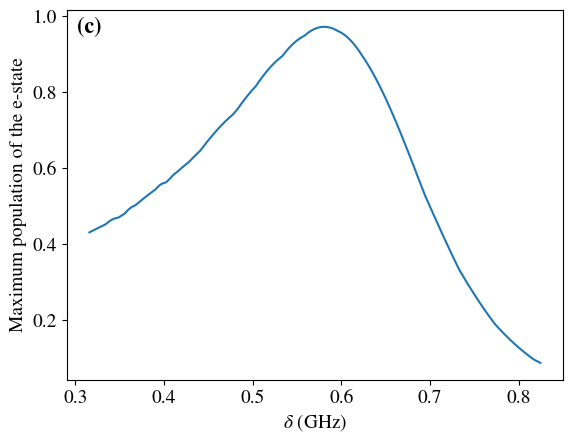

Amplitudi (GHz): 3.715969781523098
AC-stark siirtymä (GHz): 0.5808932254648269
E-tason suurin todennäköisyys: 0.9750123947789867
Pulssin pituus (ns): 25.225866891478404
Rabi-taajuus (fourier):  0.019197021188367684


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

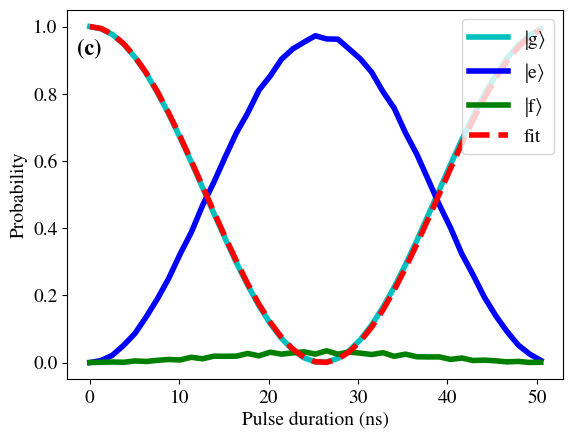

---------------------------------------------


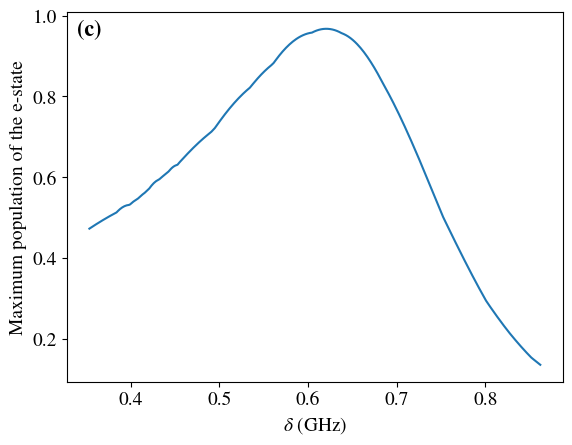

Amplitudi (GHz): 3.8367052617891915
AC-stark siirtymä (GHz): 0.6209675932040852
E-tason suurin todennäköisyys: 0.9719577379857952
Pulssin pituus (ns): 22.739866698945725
Rabi-taajuus (fourier):  0.021451527597186673


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

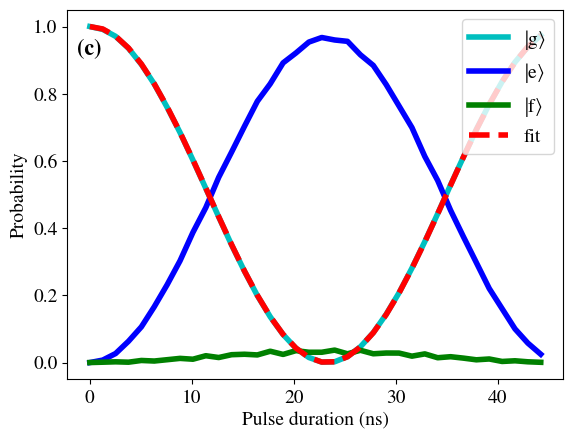

---------------------------------------------


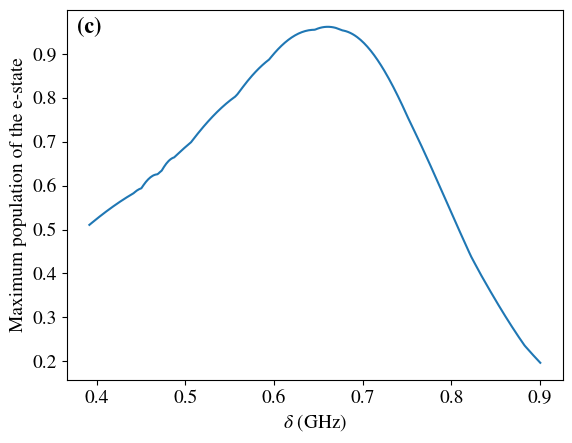

Amplitudi (GHz): 3.957440742055285
AC-stark siirtymä (GHz): 0.6608606273692814
E-tason suurin todennäköisyys: 0.9695584275411832
Pulssin pituus (ns): 21.51104912150072
Rabi-taajuus (fourier):  0.023948228291506765


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

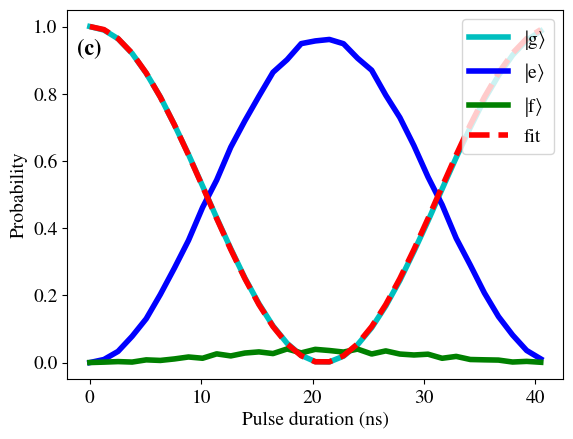

---------------------------------------------


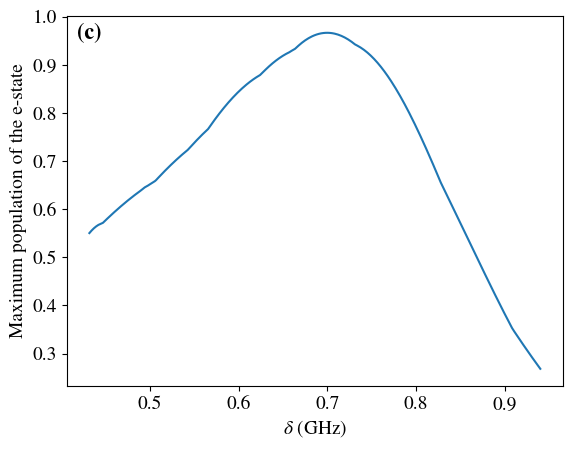

Amplitudi (GHz): 4.078176222321379
AC-stark siirtymä (GHz): 0.6992978978909719
E-tason suurin todennäköisyys: 0.9662600206694515
Pulssin pituus (ns): 19.00976758777493
Rabi-taajuus (fourier):  0.026567947383812317


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(c)')

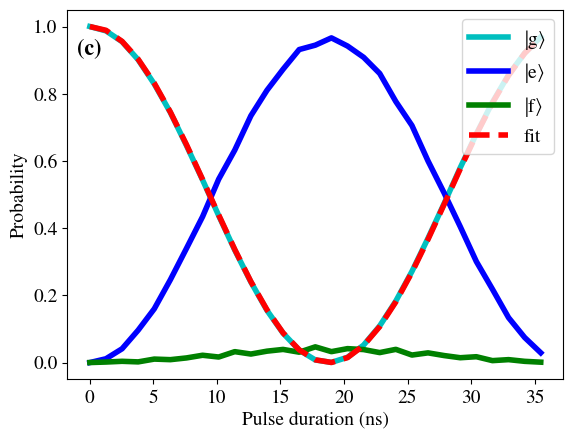

---------------------------------------------


In [8]:
deltas = [] #AC Stark siirtymät
c_vals = [] #c:n arvot
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.07
max_range = 0.16
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    c=-0.001471*A**2 - 0.001084*A + 1.002 #Arvaus c:n arvolle
    params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c)
    c_vals.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_1_opt = f_1*c_vals[-1]
    f_2_opt = f_2*c_vals[-1]

    deltas.append(qubit.frequency-2*f_1_opt+f_2_opt)

    m=10
    vals=sim_pulse(f_1_opt,f_2_opt,A,evolution_eigenbasis,dim,f_rabi/m,K=200)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
    e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
    f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 10*np.pi/(2*f_1_opt-f_2_opt) #Floquet-jakson pituus
    freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
    plt.plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
    plt.plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
    plt.plot(vals[4][:n_picked], plot_vals, ls='--', linewidth=4, color='r')
    plt.xlabel("Pulse duration (ns)")
    plt.ylabel("Probability")
    plt.legend(
        [r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "fit"],
        loc="upper right"
    )
    #print(vals[4][:n_picked])
    #print(g_vals[:n_picked])
    #print(f_vals[:n_picked])
    #print(e_vals[:n_picked])
    
    ax = plt.gca()

    ax.text(0.02, 0.92, "(c)",
        transform=ax.transAxes,
        va="top",
        fontweight="bold",
        fontsize=16)
    #plt.title("Tasojen suurimmat todennäköisyydet")
    if i==0:
        plt.savefig("resonanssi-two.pdf") 
    plt.show()

    print("---------------------------------------------")

[np.float64(1.7842020972656034), np.float64(1.9049375775316966), np.float64(2.0256730577977904), np.float64(2.1464085380638838), np.float64(2.267144018329977), np.float64(2.3878794985960705), np.float64(2.508614978862164), np.float64(2.6293504591282577), np.float64(2.7500859393943506), np.float64(2.870821419660444), np.float64(2.991556899926538), np.float64(3.112292380192631), np.float64(3.2330278604587246), np.float64(3.353763340724818), np.float64(3.474498820990912), np.float64(3.595234301257005), np.float64(3.715969781523098), np.float64(3.8367052617891915), np.float64(3.957440742055285), np.float64(4.078176222321379)]


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Amplitudi (GHz)')

Text(0, 0.5, 'delta=ω_q-2ω_1+ω_2 (GHz)')

Text(0.5, 1.0, 'AC stark siirtymä')

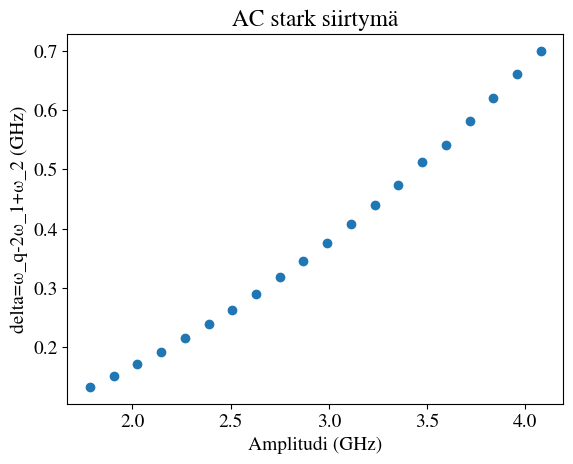

[np.float64(0.13296951744681706), np.float64(0.15173105105078122), np.float64(0.17158568115016948), np.float64(0.19253340774498184), np.float64(0.21584866090470456), np.float64(0.23898258049037935), np.float64(0.26320959657147824), np.float64(0.2898041392174946), np.float64(0.3187662084284), np.float64(0.3462725139957925), np.float64(0.3761463461280883), np.float64(0.4083877048252873), np.float64(0.43917329987896636), np.float64(0.4736008515670278), np.float64(0.5129447899589437), np.float64(0.5406375241515349), np.float64(0.5808932254648269), np.float64(0.6209675932040852), np.float64(0.6608606273692814), np.float64(0.6992978978909719)]
[np.float64(0.9947831771773263), np.float64(0.9940471017325716), np.float64(0.993268140588491), np.float64(0.9924462937450844), np.float64(0.9915315612023519), np.float64(0.9906239429602934), np.float64(0.989673439018909), np.float64(0.9886300493781986), np.float64(0.9874937740381624), np.float64(0.9864146129988002), np.float64(0.985242566260112), np.f

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Amplitudi (GHz)')

Text(0, 0.5, 'T_pulse (ns)')

Text(0.5, 1.0, 'Pi-pulssin pituus')

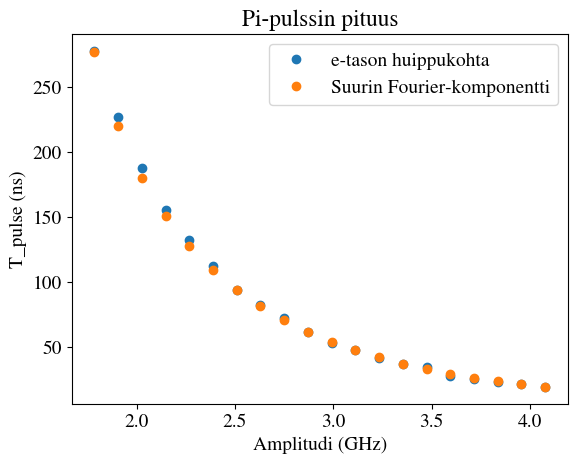

[np.float64(277.53863834074144), np.float64(226.90705202619154), np.float64(187.37614897297766), np.float64(155.24115525852778), np.float64(131.76594764195033), np.float64(111.97925044400901), np.float64(93.40566479732759), np.float64(82.28373484553151), np.float64(72.39315339068024), np.float64(61.22664323901459), np.float64(52.542410219486534), np.float64(47.599483137306244), np.float64(41.38719542718149), np.float64(36.42062162497993), np.float64(33.962270945242665), np.float64(27.703679046508913), np.float64(25.225866891478404), np.float64(22.739866698945725), np.float64(21.51104912150072), np.float64(19.00976758777493)]


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Amplitudi (GHz)')

Text(0, 0.5, 'Rabi-taajuus (GHz)')

Text(0.5, 1.0, 'Rabi taajuus')

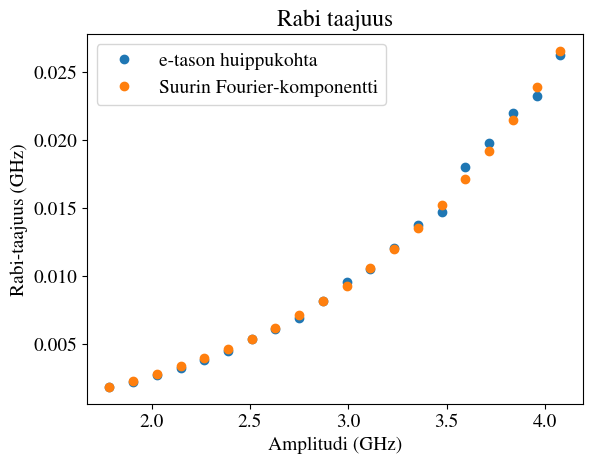

[np.float64(0.0018067938874667755), np.float64(0.0022737457890295953), np.float64(0.002775975331946544), np.float64(0.003323148378114987), np.float64(0.003926094214052219), np.float64(0.004595313487297139), np.float64(0.005342309774152593), np.float64(0.006170020219006604), np.float64(0.007096374997125256), np.float64(0.00813318276703244), np.float64(0.009284021726659717), np.float64(0.010559894131530025), np.float64(0.01197219309936796), np.float64(0.013541704037618452), np.float64(0.015259114029881183), np.float64(0.017151584316412824), np.float64(0.019197021188367684), np.float64(0.021451527597186673), np.float64(0.023948228291506765), np.float64(0.026567947383812317)]


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pi-pulssin pituus (GHz)')

Text(0, 0.5, 'P')

Text(0.5, 1.0, 'Tasojen suurimmat todennäköisyydet')

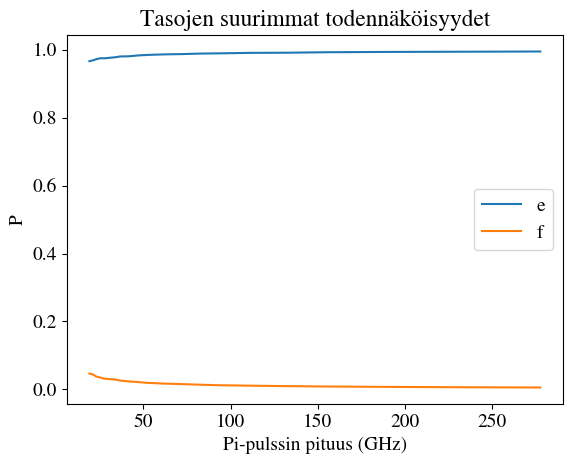

[np.float64(0.9948738131217567), np.float64(0.9941291228200401), np.float64(0.9935623419690238), np.float64(0.9927109879609143), np.float64(0.9912990907478213), np.float64(0.9908683356725931), np.float64(0.9894382309963332), np.float64(0.9887136051365525), np.float64(0.987290220645149), np.float64(0.9862995394978299), np.float64(0.9848331493835315), np.float64(0.9835451106069514), np.float64(0.9807161498847845), np.float64(0.9802004560228311), np.float64(0.9779371864046491), np.float64(0.9749131961639426), np.float64(0.9750123947789867), np.float64(0.9719577379857952), np.float64(0.9695584275411832), np.float64(0.9662600206694515)]
[np.float64(0.005640907769040581), np.float64(0.006531297363378577), np.float64(0.007501992215652309), np.float64(0.008554843005201705), np.float64(0.009704046855211024), np.float64(0.010996237461302462), np.float64(0.012350150155448995), np.float64(0.013870254033688979), np.float64(0.015576578011228782), np.float64(0.01731382963868938), np.float64(0.0192625

In [9]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

[np.float64(0.4003565351118965), np.float64(0.39908210504241737), np.float64(0.39780767497295244), np.float64(0.3965332449034733), np.float64(0.39525881483400127), np.float64(0.39398438476452213), np.float64(0.392709954695043), np.float64(0.39143552462557096), np.float64(0.3901610945560918), np.float64(0.3888866644866127), np.float64(0.38761223441714066), np.float64(0.3863378043476615), np.float64(0.3850633742781966), np.float64(0.38378894420871745), np.float64(0.3825145141392454), np.float64(0.3812400840697663), np.float64(0.37996565400028715), np.float64(0.3786912239308151), np.float64(0.377416793861336), np.float64(0.37614236379186394), np.float64(0.3748679337223848), np.float64(0.3735935036529128), np.float64(0.37231907358344074), np.float64(0.3710446435139687), np.float64(0.36977021344448957), np.float64(0.36849578337501043), np.float64(0.3672213533055384), np.float64(0.36594692323605926), np.float64(0.36467249316658723), np.float64(0.3633980630971081), np.float64(0.36212363302762

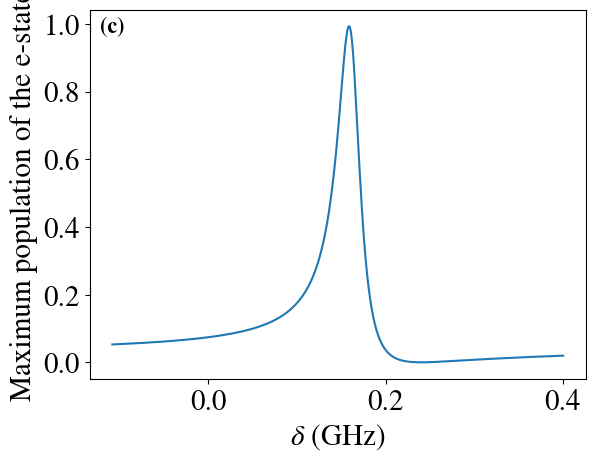

Rabi-taajuus (fourier):  0.002383368914022106


<Figure size 800x800 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0.02, 0.92, '(c)')

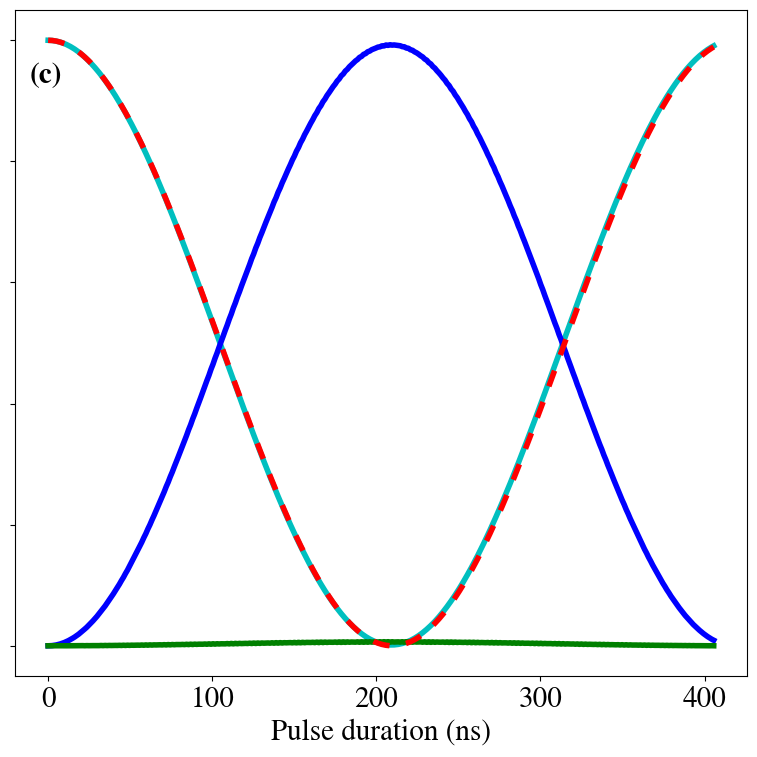

---------------------------------------------


In [13]:
A = 1.95

f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
c=-0.001471*A**2 - 0.001084*A + 1.002 #Arvaus c:n arvolle
params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c)

f_1_opt = f_1*params[0]
f_2_opt = f_2*params[0]

m=100
vals=sim_pulse(f_1_opt,f_2_opt,A,evolution_eigenbasis,dim,f_rabi/m,K=200)

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

#Taajuusavaruus
T_floquet = 10*np.pi/(2*f_1_opt-f_2_opt) #Floquet-jakson pituus
freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

plt.figure(figsize=(8, 8))
plt.plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
plt.plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
plt.plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
plt.plot(vals[4][:n_picked], plot_vals, ls='--', dashes=(3, 3), linewidth=4, color='r')
plt.xlabel("Pulse duration (ns)")
#plt.ylabel("Probability")
#plt.legend([r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "fit"],loc="upper right")

#print(vals[4][:n_picked])
#print(g_vals[:n_picked])
#print(f_vals[:n_picked])
#print(e_vals[:n_picked])

ax = plt.gca()
ax.tick_params(axis='y', which='both', left=True, labelleft=False)

ax.text(0.02, 0.92, "(c)",
    transform=ax.transAxes,
    va="top",
    fontweight="bold")
#plt.title("Tasojen suurimmat todennäköisyydet")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("resonanssi-two.pdf") 
plt.show()

print("---------------------------------------------")